# **COVID-19 HOSPITALIZATION PREDICTION - MEXICO SISVER DATASET**
**Machine Learning 2026 — Course Project**

Dataset: [Mexico COVID-19 Clinical Data](https://www.kaggle.com/datasets/marianarfranklin/mexico-covid19-clinical-data) (SISVER, Mexico Secretariat of Health)

Task: Predict whether a patient is hospitalized (binary classification).

**Reproducibility note:** run this notebook top to bottom with no manual edits. Seeds are fixed in the setup cell below.

**Push new version to github:** <br>
git status
git add project_notebook.ipynb
git commit -m "19.07 noon"
git push

**IMPORTS AND SEED**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import sklearn

# random seeds
random_state = 42

# test size for inital, preliminary comparisons/ test
test_size = 0.2


**LOAD THE DATASET** CSV which has been downloaded from Kaggle:
https://www.kaggle.com/datasets/marianarfranklin/mexico-covid19-clinical-data

In [2]:
# load the dataset
data_path = "../dataset/mexico_covid19.csv"
download_date = "2026-07-11"

df_raw = pd.read_csv(data_path, sep=None, engine="python", encoding="utf-8")
# fix for encoding issue in 'PAIS_NACIONALIDAD'
df_raw["PAIS_NACIONALIDAD"] = df_raw["PAIS_NACIONALIDAD"].str.encode("latin-1", errors="ignore").str.decode("utf-8", errors="ignore")
df = df_raw.copy()

df

,id,FECHA_ARCHIVO,ID_REGISTRO,ENTIDAD_UM,ENTIDAD_RES,RESULTADO,DELAY,ENTIDAD_REGISTRO,ENTIDAD,ABR_ENT,...,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,9269,2020-04-12,00011f,25,25,2,0,25,Sinaloa,SL,...,2,2,1,2,2,2,99,México,97,97
1,33333,2020-04-12,00014e,14,14,2,0,14,Jalisco,JC,...,2,2,1,2,1,99,99,México,97,2
2,35483,2020-04-12,000153,8,8,1,0,8,Chihuahua,CH,...,2,2,2,2,2,99,99,México,97,2
3,7062,2020-04-12,0001b6,9,15,1,0,9,Ciudad de Mexico,DF,...,2,2,1,2,2,99,99,México,97,97
4,23745,2020-04-12,0001c1,9,9,2,0,9,Ciudad de Mexico,DF,...,2,2,2,2,2,99,99,México,97,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263002,7094887,2020-06-03,1e019c,32,32,1,0,32,Zacatecas,ZS,...,2,2,2,2,2,1,99,México,99,97
263003,7053721,2020-06-03,1e2b05,12,12,1,0,12,Guerrero,GR,...,2,2,1,2,2,99,99,México,99,2
263004,7055429,2020-06-03,1e473f,20,20,1,0,20,Oaxaca,OC,...,2,2,2,1,2,99,99,México,99,2
263005,7043768,2020-06-03,1e6da1,13,13,1,0,13,Hidalgo,HG,...,2,2,2,2,2,2,99,México,99,2


## **1. DATA ANALYSIS**

#### **1.1 HIGH-LEVEL STATISTICS**
- Number of observations: 263.007 patients
- Missing values per column: MUNICIPIO_RES is missing 6 entries
- Target distribution (class balance): 1 --> 76,36%, 2 --> 23,64%

In [4]:
#number of observations
df["ORIGEN"].value_counts()

ORIGEN
2    167217
1     95790
Name: count, dtype: int64

In [5]:
#find missing data
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False) 
missing

MUNICIPIO_RES    6
dtype: int64

In [6]:
#target distribution
df["TIPO_PACIENTE"].value_counts(normalize=True)

TIPO_PACIENTE
1    0.763622
2    0.236378
Name: proportion, dtype: float64

#### **1.2 LEAKAGE AUDIT**
**Important and Potentially Problematic Variables:**


| Variable | Available at prediction time? | Included? | Reason |
|---|---|---|---|
| EDAD | Yes | Yes | Baseline information |
| DIABETES | Yes | Yes | Pre-existing condition |
| SECTOR | Yes | No | Describes institution, not patient |
| NEUMONIA | No | No | Downstream of admission |
| INTUBADO | No | No | Downstream of hospitalization |
| RESULTADO | No | No | Shares unobserved cause with the target |
| UCI | No | No | Downstream of hospitalization |
| FECHA_DEF | No | No | Downstream of hospitalization |

#### **1.3 EXPLORATORY PLOTS**
**Plots visualizing first broad characteristics of dataset.**

**1: Target Distribution: Hospitalization Status** 
<br>
Understand Prediction Task

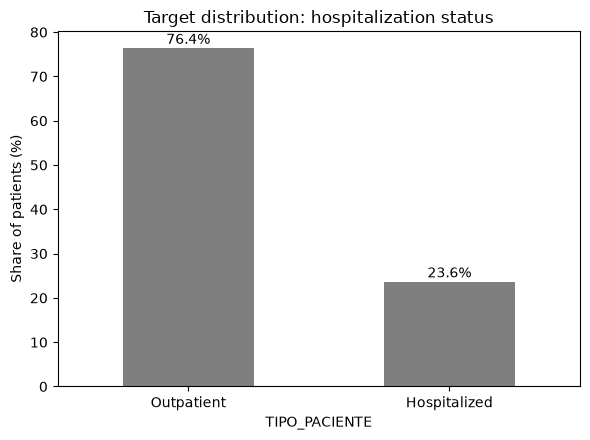

In [ ]:
# plot der verteilung von outpatient und hospitalisierung
pct = df["TIPO_PACIENTE"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4.5))
pct.plot(kind="bar", color="#7F7F7F", ax=ax)
plt.xticks([0, 1], ["Outpatient", "Hospitalized"], rotation=0)
plt.ylabel("Share of patients (%)")
plt.title("Target distribution: hospitalization status")

for i, v in enumerate(pct):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

# 1 ambulant
# 2 hospitalisiert

# 1 positiv
# 2 negativ

**2: Hospitalisation Rate per Resultado Group**<br>
Reveal Potential Confounders

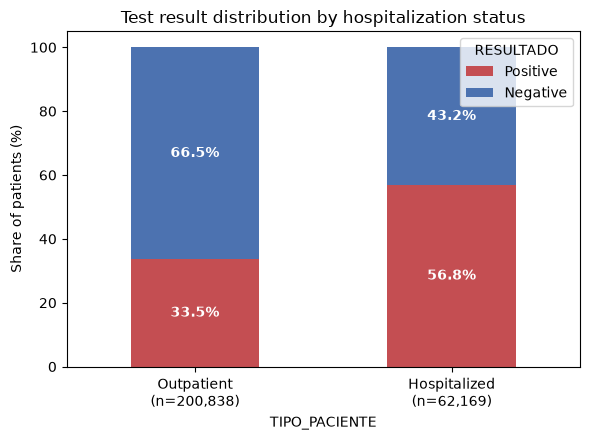

In [12]:
import matplotlib.pyplot as plt

result_share = df.groupby("TIPO_PACIENTE")["RESULTADO"].value_counts(normalize=True).unstack() * 100
result_share
group_counts = df["TIPO_PACIENTE"].value_counts()
group_counts
fig, ax = plt.subplots(figsize=(6, 4.5))
result_share.plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"], ax=ax, width=0.5)

labels = [
    f"Outpatient\n(n={group_counts[1]:,})",
    f"Hospitalized\n(n={group_counts[2]:,})"
]
ax.set_xticklabels(labels, rotation=0)

for i, tipo in enumerate(result_share.index):
    cum = 0
    for col in result_share.columns:
        val = result_share.loc[tipo, col]
        ax.text(i, cum + val / 2, f"{val:.1f}%", ha="center", va="center",
                color="white", fontweight="bold")
        cum += val

plt.ylabel("Share of patients (%)")
plt.title("Test result distribution by hospitalization status")
plt.legend(["Positive", "Negative"], title="RESULTADO", loc="upper right")
plt.tight_layout()
plt.show()

**3: Preprocessing Evaluation**

HABLA_LENGUA_INDIG     2.671032
ENTIDAD_NAC            4.768314
PAIS_NACIONALIDAD      7.116160
OTRO_CASO             31.601440
EMBARAZO              51.278483
INTUBADO              76.376674
UCI                   76.377435
MIGRANTE              99.582521
PAIS_ORIGEN           99.863502


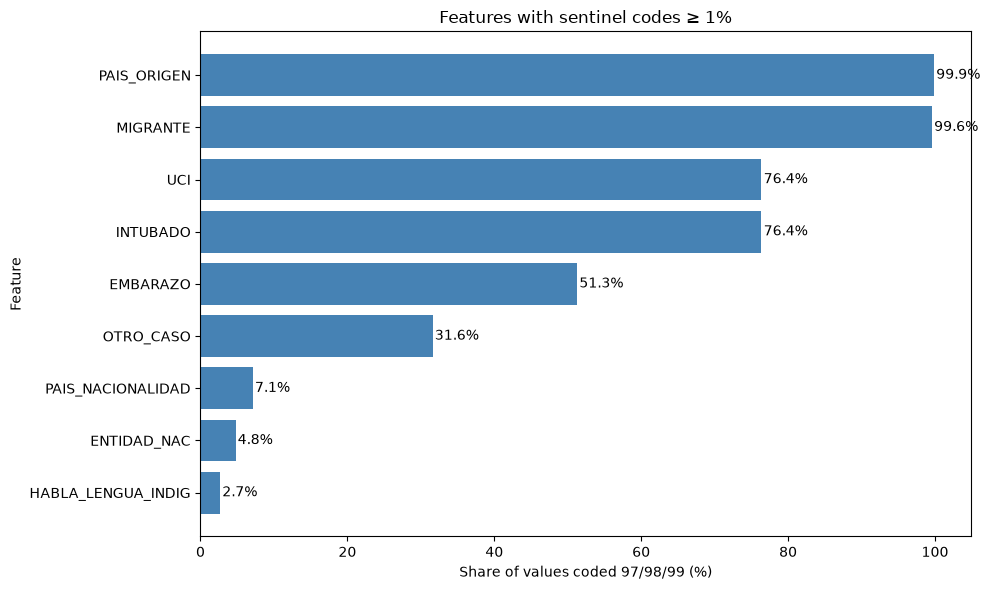

In [ ]:
# 97    NOT APPLICABLE
# 98    IGNORED / UNKNOWN
# 99    NOT SPECIFIED
# 97 = NO APLICA: „trifft nicht zu“ / „nicht anwendbar“.

# 98 = SE IGNORA: „wird ignoriert“ / „wird nicht berücksichtigt“.

# 99 = NO ESPECIFICADO: „nicht spezifiziert“ / „nicht angegeben“

# 97    NOT APPLICABLE
# 98    IGNORED / UNKNOWN
# 99    NOT SPECIFIED

import pandas as pd
import matplotlib.pyplot as plt

sentinel_codes = [97, 98, 99]

pct = {}
for col in df.columns:
    s = df[col]
    if pd.api.types.is_numeric_dtype(s):
        pct[col] = s.isin(sentinel_codes).mean() * 100
    else:
        pct[col] = s.astype(str).str.strip().isin(['97', '98', '99']).mean() * 100

sentinel_pct = pd.Series(pct).sort_values(ascending=True)
sentinel_pct = sentinel_pct[sentinel_pct >= 1]

print(sentinel_pct.to_string())

fig, ax = plt.subplots(figsize=(10, max(6, len(sentinel_pct) * 0.25)))
bars = ax.barh(sentinel_pct.index, sentinel_pct.values, color='steelblue')

for bar, pct_val in zip(bars, sentinel_pct.values):
    label = f'{pct_val:.1f}%'
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center'
    )

ax.set_xlabel('Share of values coded 97/98/99 (%)')
ax.set_ylabel('Feature')
ax.set_title('Features with sentinel codes ≥ 1%')
plt.tight_layout()
plt.show()

#### **1.4 RESULTADO INFLUENCE WITH PHI-COEFFICIENCY** 

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

# Kontingenztabelle zwischen RESULTADO und TIPO_PACIENTE
contingency = pd.crosstab(df['RESULTADO'], df['TIPO_PACIENTE'])

chi2, p, dof, expected = chi2_contingency(contingency)

n = contingency.sum().sum()
phi = np.sqrt(chi2 / n)
print(f"Phi coefficient: {phi:.3f}, p-value: {p:.2e}")

Phi coefficient: 0.202, p-value: 0.00e+00


: 

## **2. PRE-PROCESSING**

- removal of a selection of features
- addition of feature "DIAS_CON_SINTOMAS"

In [3]:
target = 'TIPO_PACIENTE'
# add "DIAS_CON_SINTOMAS" feature, consisting of FECHA_INGRESO substracted by FECHA_SINTOMAS
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'], format='%Y-%m-%d', errors='coerce')
df['FECHA_SINTOMAS'] = pd.to_datetime(df['FECHA_SINTOMAS'], format='%Y-%m-%d', errors='coerce')
df['DIAS_CON_SINTOMAS'] = (df['FECHA_INGRESO'] - df['FECHA_SINTOMAS']).dt.days

# remove pre-selected features (find reasoning in supplementary table in report)
included_features = [
    'SEXO', 'EDAD', 'EMBARAZO',
    'DIABETES', 'EPOC', 'ASMA', 'INMUSUPR', 'HIPERTENSION',
    'OTRA_COM', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA',
    'TABAQUISMO', 'OTRO_CASO', 
    'DIAS_CON_SINTOMAS'
]

df_model = df[included_features].copy()
df_model.describe()

,SEXO,EDAD,EMBARAZO,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,DIAS_CON_SINTOMAS
count,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000,263007.000000
mean,1.510682,42.591627,50.708825,2.239712,2.320102,2.300711,2.359667,2.174185,2.453961,2.324980,2.184763,2.320231,2.268217,32.283764,3.584794
std,0.499887,16.903824,47.494775,5.958047,5.704424,5.682309,6.021830,5.745114,6.850231,5.796086,5.817362,5.722995,5.867586,45.350310,3.240126
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,31.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000
50%,2.000000,41.000000,97.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
75%,2.000000,53.000000,97.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,99.000000,5.000000
max,2.000000,120.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,99.000000,115.000000


## **3. MODEL COMPARISON**

**LOGISTIC REGRESSION VS K-NN VS RANDOM FOREST ON PRELIMINARY, RANDOM 80/20 SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

y = (df['TIPO_PACIENTE'] == 2).astype(int)
X = df_model.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

scaler = StandardScaler()s
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

max_iter = 1000
n_estimator = 200
n_neighbors = 15

models = {
    'Baseline (majority class)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=max_iter),
    'Random Forest': RandomForestClassifier(n_estimators=n_estimator, random_state=random_state),
    'k-NN': KNeighborsClassifier(n_neighbors=n_neighbors),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
    }
 
results_df = pd.DataFrame(results).T
print(results_df)

# takes roughly 3.5-7.5 minutes
#
#                             ROC-AUC        F1  Precision    Recall
# Baseline (majority class)  0.500000  0.000000   0.000000  0.000000
# Logistic Regression        0.737141  0.383285   0.701240  0.263712
# Random Forest              0.793007  0.537923   0.618853  0.475712
# k-NN                       0.799545  0.512120   0.665296  0.416278

                            ROC-AUC        F1  Precision    Recall
Baseline (majority class)  0.500000  0.000000   0.000000  0.000000
Logistic Regression        0.737141  0.383285   0.701240  0.263712
Random Forest              0.793007  0.537923   0.618853  0.475712
k-NN                       0.799545  0.512120   0.665296  0.416278


## **4. PIPELINE**

#### **4.1 TEMPORAL SPLIT**


**Performing a temportal split at week 2020-05-18** <br> hier noch checken ob preprocessing hier nicht auch rein muss

In [9]:
# Sortieren und splitten mit df (enthält FECHA_INGRESO)
df_pipeline = df.sort_values('FECHA_INGRESO')

split_date = '2020-05-18'
learning_mask = df_pipeline['FECHA_INGRESO'] < split_date
test_mask = df_pipeline['FECHA_INGRESO'] >= split_date

df_learning = df_pipeline[learning_mask]
df_test = df_pipeline[test_mask]

# Erst danach: Feature-Auswahl anwenden (gleiche Liste wie df_model)
X_learning = df_learning[included_features]
y_learning = (df_learning['TIPO_PACIENTE'] == 2).astype(int)

X_test = df_test[included_features]
y_test = (df_test['TIPO_PACIENTE'] == 2).astype(int)

# Indices speichern, bevor irgendeine Modellauswahl beginnt
train_idx = X_learning.index
test_idx = X_test.index

np.save('train_idx.npy', train_idx.to_numpy())
np.save('test_idx.npy', test_idx.to_numpy())

print(f"Learning set: {len(X_learning)} ({len(X_learning)/len(df)*100:.2f}%)")
print(f"Test set: {len(X_test)} ({len(X_test)/len(df)*100:.2f}%)")

Learning set: 178505 (67.87%)
Test set: 84502 (32.13%)


#### **4.2 IMPUTING AND ENCODING**

**Imputing features with small shares in sentinel codes and encoding features with high shares in sentinel codes among data points**

In [10]:
# imputing and encoding

sentinel_codes = [97,98,99]

small_missing_features = ['DIABETES', 'EPOC', 'INMUSUPR', 'HIPERTENSION', 'OTRA_COM','CARDIOVASCULAR','OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO']

structural_missing_features = ['EMBARAZO', 'OTRO_CASO']

from sklearn.base import BaseEstimator, TransformerMixin

class SentinelHandler (BaseEstimator, TransformerMixin):
  
  def fit(self, X, y=None):
    mask = X[small_missing_features].isin(sentinel_codes)
    X_temp = X[small_missing_features].where(~mask, np.nan)
    self.modes = X_temp.mode().iloc[0]
    return self
  
  def transform(self, X):
    X = X.copy()
    mask_small = X[small_missing_features].isin(sentinel_codes)
    X[small_missing_features] = X[small_missing_features].where(~mask_small, np.nan)
    X[small_missing_features] = X[small_missing_features].fillna(self.modes)

    mask_structural = X[structural_missing_features].isin(sentinel_codes)
    X[structural_missing_features] = X[structural_missing_features].where(~mask_structural, 3)

    return X

#### **4.3 CROSS VALIDATION**

**Creating Cross Validation Strategy adapted to split decision**

In [11]:
# Woche basierend auf FECHA_INGRESO zuweisen (gleiche Spalte, die für den Split genutzt wurde)
learning_weeks = df_learning['FECHA_INGRESO'].dt.to_period('W')
# make list with week entries that can be later referenced to with unique_weeks[index]
unique_weeks = learning_weeks.value_counts().sort_index().index.tolist()

# Walk-Forward Folds bauen: Fold i = Train auf Wochen 1..i, Validation auf Woche i+1
cv_splits = []

for i in range(1, len(unique_weeks)):
    train_weeks = unique_weeks[:i]
    val_week = unique_weeks[i]

    train_fold_mask = learning_weeks.isin(train_weeks)
    val_fold_mask = learning_weeks == val_week

    # Positionen (nicht Original-Indices!) -- das braucht sklearn für GridSearchCV
    train_pos = np.where(train_fold_mask.values)[0]
    val_pos = np.where(val_fold_mask.values)[0]

    cv_splits.append((train_pos, val_pos))

# Zusammenfassung:
# die positionsarrays train_pos und val_pos geben uns die indizes in learning_weeks an, 
# die uns für jeden einzelnen fold sagen, welche zeilen in diesem fold zu training und zu validation gehören
print(f"Amount: {len(cv_splits)}")
for i, (tr, va) in enumerate(cv_splits):
    print(f"Fold {i+1}: Train size={len(tr)}, Val size={len(va)}")

Amount: 19
Fold 1: Train size=60, Val size=184
Fold 2: Train size=244, Val size=272
Fold 3: Train size=516, Val size=315
Fold 4: Train size=831, Val size=221
Fold 5: Train size=1052, Val size=211
Fold 6: Train size=1263, Val size=263
Fold 7: Train size=1526, Val size=170
Fold 8: Train size=1696, Val size=282
Fold 9: Train size=1978, Val size=455
Fold 10: Train size=2433, Val size=1235
Fold 11: Train size=3668, Val size=3436
Fold 12: Train size=7104, Val size=8193
Fold 13: Train size=15297, Val size=10630
Fold 14: Train size=25927, Val size=12602
Fold 15: Train size=38529, Val size=17342
Fold 16: Train size=55871, Val size=21534
Fold 17: Train size=77405, Val size=26872
Fold 18: Train size=104277, Val size=33916
Fold 19: Train size=138193, Val size=40312


#### **4.4 PIPELINE FITTING**

In [12]:
# pipeline
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('sentinel_handler', SentinelHandler()),
    ('model', RandomForestClassifier(n_estimators=200, random_state=random_state))
])

pipeline.fit(X_learning, y_learning)
print("Pipeline erfolgreich gefittet.")
print("Score auf Learning Set:", pipeline.score(X_learning, y_learning))

Pipeline erfolgreich gefittet.
Score auf Learning Set: 0.8863617265622812


#### **4.5 HYPERPARAMETER SEARCH**

**Search for hyperparameters for final run**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('sentinel_handler', SentinelHandler()),
    ('model', RandomForestClassifier(n_estimators=200, random_state=random_state))
])

param_grid = {
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [1, 5, 10],
}
# 3 x 3 = 9 Kombinationen x 19 Folds = 171 Modelle

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_splits,
    scoring=['roc_auc','f1','recall','precision'],
    refit = 'roc_auc', # fits model
    return_train_score=True,
    n_jobs=1,
    verbose=2,
    error_score='raise'  # zeigt den vollen Fehler statt nur NaN

)

grid_search.fit(X_learning, y_learning)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)


# shows best configuration of each metric
results_df = pd.DataFrame(grid_search.cv_results_)

metrics = ['roc_auc', 'f1', 'recall', 'precision']  

for metric in metrics:
    best_idx_for_metric = results_df[f'mean_test_{metric}'].idxmax()
    best_params_for_metric = results_df.loc[best_idx_for_metric, 'params']
    best_score_for_metric = results_df.loc[best_idx_for_metric, f'mean_test_{metric}']
    print(f"Best config for {metric}: {best_params_for_metric} -> {best_score_for_metric:.4f}")

# these are the values:
# Best config for roc_auc: {'model__max_depth': None, 'model__min_samples_leaf': 5} -> 0.8287
# Best config for f1: {'model__max_depth': None, 'model__min_samples_leaf': 5} -> 0.6558
# Best config for recall: {'model__max_depth': None, 'model__min_samples_leaf': 5} -> 0.6114
# Best config for precision: {'model__max_depth': 5, 'model__min_samples_leaf': 5} -> 0.7684


Fitting 19 folds for each of 9 candidates, totalling 171 fits
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.3s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.4s
[CV] END ......model__max_depth=5, model__min_samples_leaf=1; total time=   0.5s
[CV] END ......model__max_depth=5, model__min_s

#### **4.6 FINAL EVALUATION ON TEST-SET**

In [22]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

final_model = grid_search.best_estimator_

y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)

print("Final Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("Final Test F1:", f1_score(y_test, y_test_pred))
print("Final Test Precision:", precision_score(y_test, y_test_pred))
print("Final Test Recall:", recall_score(y_test, y_test_pred))

Final Test ROC-AUC: 0.8331129812455411
Final Test F1: 0.5268118059614261
Final Test Precision: 0.6104808669150017
Final Test Recall: 0.46331277306604984


#### **4.7 ERROR-ANALYSIS**

##### **4.7.1 IMPORTANCE ANALYSIS OF FEATURES**

In [ ]:
# importance of features
importances = pd.Series(
    final_model.named_steps['model'].feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print(importances)

EDAD                 0.357268
OTRO_CASO            0.259172
DIAS_CON_SINTOMAS    0.125014
DIABETES             0.087574
HIPERTENSION         0.046808
RENAL_CRONICA        0.024920
INMUSUPR             0.017074
EMBARAZO             0.015923
SEXO                 0.015212
EPOC                 0.013202
OBESIDAD             0.010930
OTRA_COM             0.008622
CARDIOVASCULAR       0.006677
ASMA                 0.006635
TABAQUISMO           0.004970
dtype: float64


##### **4.7.2 PREDICTED PROBABILITIES FOR ACTUALLY HOSPITALIZED PATIENTS**

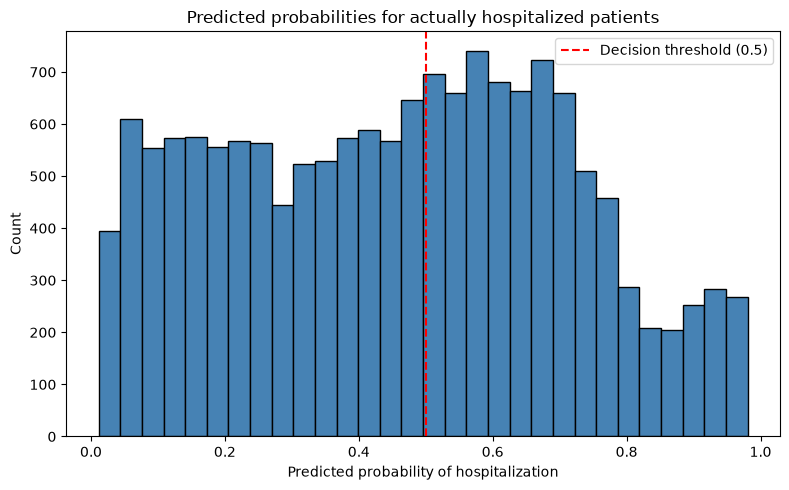

False Negatives gesamt: 8353
Davon 'knapp' (0.3-0.5): 3539
Davon 'weit daneben' (<0.3): 4814


In [ ]:
import matplotlib.pyplot as plt

# Wahrscheinlichkeiten nur für die tatsächlich HOSPITALISIERTEN Patienten (y_test == 1)
proba_actual_positive = y_test_proba[y_test == 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(proba_actual_positive, bins=30, color='steelblue', edgecolor='black')
ax.axvline(0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
ax.set_xlabel('Predicted probability of hospitalization')
ax.set_ylabel('Count')
ax.set_title('Predicted probabilities for actually hospitalized patients')
ax.legend()
plt.tight_layout()
plt.show()

# Zusätzlich: wie viele False Negatives sind "knapp" (0.3-0.5) vs. "weit daneben" (<0.3)?
false_negatives_proba = proba_actual_positive[proba_actual_positive < 0.5]
print(f"False Negatives gesamt: {len(false_negatives_proba)}")
print(f"Davon 'knapp' (0.3-0.5): {((false_negatives_proba >= 0.3) & (false_negatives_proba < 0.5)).sum()}")
print(f"Davon 'weit daneben' (<0.3): {(false_negatives_proba < 0.3).sum()}")
# import pandas as pd

In [52]:
fn_mask = (y_test == 1) & (y_test_proba < 0.5)

print(X_test.loc[fn_mask, 'DIAS_CON_SINTOMAS'].mean())
print(X_test.loc[y_test == 1, 'DIAS_CON_SINTOMAS'].mean())

print(X_test.loc[fn_mask, 'OTRO_CASO'].value_counts(normalize=True))
print(X_test.loc[y_test == 1, 'OTRO_CASO'].value_counts(normalize=True))

4.344546869388243
4.106913389874069
OTRO_CASO
2     0.436729
1     0.309350
99    0.253921
Name: proportion, dtype: float64
OTRO_CASO
99    0.426240
2     0.401118
1     0.172642
Name: proportion, dtype: float64


##### **4.7.3 CALCULATION OF MEANS IN FALSE NEGATIVE AND TRUE POSITIVE PREDICTIONS**

In [51]:
# means in (0; 0.5) interval
fn_mask = (y_test == 1) & (y_test_proba < 0.5)

# EDAD-Verteilung bei allen False Negatives
print("EDAD Verteilung bei allen False Negatives:")
print(X_test.loc[fn_mask, 'EDAD'].mean())

# Zum Vergleich: EDAD-Verteilung bei ALLEN tatsächlich hospitalisierten Patienten
print("\nEDAD Verteilung bei ALLEN tatsächlich hospitalisierten Patienten:")
print(X_test.loc[y_test == 1, 'EDAD'].mean())

# DIABETES and HIPERTENSION Verteilung bei allen False Negatives
print("\nDIABETES Verteilung bei allen False Negatives:")
print(X_test.loc[fn_mask, 'DIABETES'].value_counts(normalize=True))
print("\nHIPERTENSION Verteilung bei allen False Negatives:")
print(X_test.loc[fn_mask, 'HIPERTENSION'].value_counts(normalize=True))

# # Zum Vergleich: Verteilung bei ALLEN tatsächlich hospitalisierten Patienten
print("\nDIABETES Verteilung bei ALLEN tatsächlich hospitalisierten Patienten:")
print(X_test.loc[y_test == 1, 'DIABETES'].value_counts(normalize=True))
print("\nHIPERTENSION Verteilung bei ALLEN tatsächlich hospitalisierten Patienten:")
print(X_test.loc[y_test == 1, 'HIPERTENSION'].value_counts(normalize=True))

# diabetes und hipertension: höher bei den richtig vorhergesagten, niedriger bei falsch --> model biased dass diabetiker und menshen mit bluthochdruck eher hospitalisiert werden müssen

EDAD Verteilung bei allen False Negatives:
45.81683227582904

EDAD Verteilung bei ALLEN tatsächlich hospitalisierten Patienten:
53.08616037008481

DIABETES Verteilung bei allen False Negatives:
DIABETES
2     0.841015
1     0.152281
98    0.006704
Name: proportion, dtype: float64

HIPERTENSION Verteilung bei allen False Negatives:
HIPERTENSION
2     0.788220
1     0.206872
98    0.004908
Name: proportion, dtype: float64

DIABETES Verteilung bei ALLEN tatsächlich hospitalisierten Patienten:
DIABETES
2     0.700720
1     0.293241
98    0.006040
Name: proportion, dtype: float64

HIPERTENSION Verteilung bei ALLEN tatsächlich hospitalisierten Patienten:
HIPERTENSION
2     0.663775
1     0.331277
98    0.004947
Name: proportion, dtype: float64


## **Supplementary Tables**

#### **1. Cumulative, relative and absolute numbers for hospitalization and patients**

Cumulative, relative and absolute numbers for hospitalization and patients

In [25]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'])
df['week'] = df['FECHA_INGRESO'].dt.to_period('W')

df['is_hospitalized'] = (df['TIPO_PACIENTE'] == 2).astype(int)

weekly = df.groupby('week').agg(
    n_patients=('is_hospitalized', 'size'),
    n_hospitalized=('is_hospitalized', 'sum')
)

weekly['hospitalization_rate_%'] = 100 * weekly['n_hospitalized'] / weekly['n_patients']

weekly['cumulative_n'] = weekly['n_patients'].cumsum()
weekly['cumulative_pct'] = 100 * weekly['cumulative_n'] / len(df)

weekly['cumulative_hospitalized'] = weekly['n_hospitalized'].cumsum()
weekly['cumulative_hospitalization_rate_%'] = (
    100 * weekly['cumulative_hospitalized'] / weekly['cumulative_n']
)

weekly = weekly.reset_index()

# Runden auf 2 Nachkommastellen
weekly = weekly.round(2)

# cumulative_pct (und optional die anderen Raten) als Prozent-String darstellen
weekly['cumulative_pct'] = weekly['cumulative_pct'].map(lambda x: f"{x:.2f}%")

weekly

C:\Users\gewue\AppData\Local\Temp\ipykernel_3416\4001246534.py:29: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  weekly = weekly.round(2)


,week,n_patients,n_hospitalized,hospitalization_rate_%,cumulative_n,cumulative_pct,cumulative_hospitalized,cumulative_hospitalization_rate_%
0,2019-12-30/2020-01-05,60,35,58.33,60,0.02%,35,58.33
1,2020-01-06/2020-01-12,184,100,54.35,244,0.09%,135,55.33
2,2020-01-13/2020-01-19,272,122,44.85,516,0.20%,257,49.81
3,2020-01-20/2020-01-26,315,173,54.92,831,0.32%,430,51.74
4,2020-01-27/2020-02-02,221,120,54.30,1052,0.40%,550,52.28
5,2020-02-03/2020-02-09,211,106,50.24,1263,0.48%,656,51.94
6,2020-02-10/2020-02-16,263,137,52.09,1526,0.58%,793,51.97
7,2020-02-17/2020-02-23,170,87,51.18,1696,0.64%,880,51.89
8,2020-02-24/2020-03-01,282,112,39.72,1978,0.75%,992,50.15
9,2020-03-02/2020-03-08,455,144,31.65,2433,0.93%,1136,46.69


## **Supplementary Plots**

#### **1. Hospitalization rate by age group and Diabetes prevalence by age group**

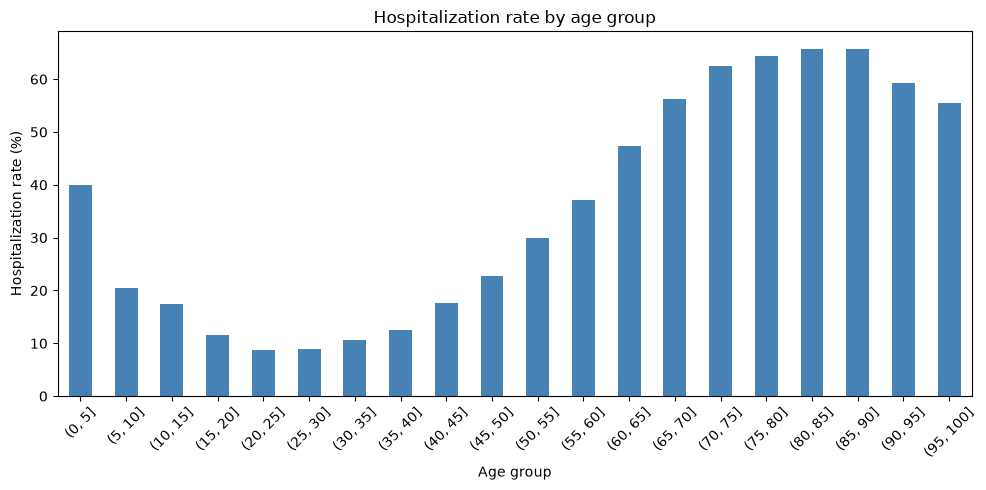

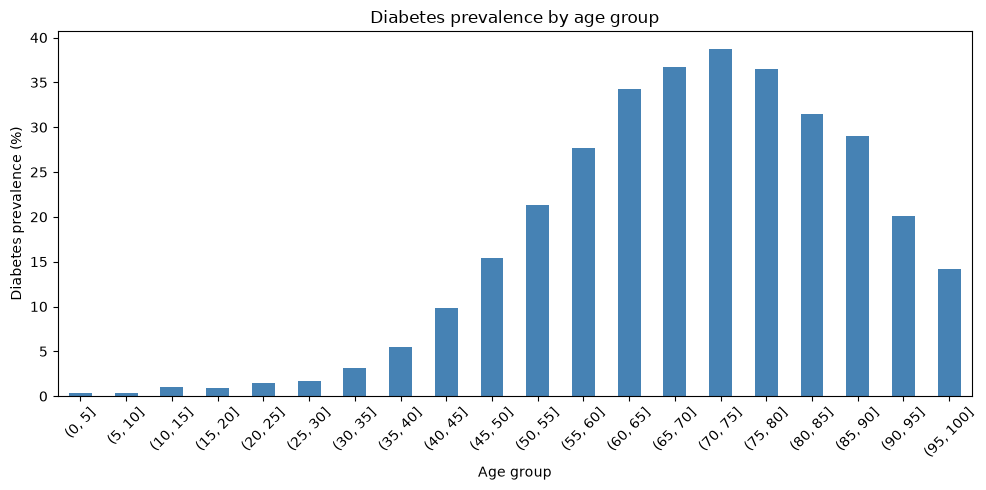

In [8]:
import matplotlib.pyplot as plt

# Alter in Bins gruppieren, Hospitalisierungsrate pro Bin berechnen
df['AGE_BIN'] = pd.cut(df['EDAD'], bins=range(0, 101, 5))
hosp_rate_by_age = df.groupby('AGE_BIN')['TIPO_PACIENTE'].apply(lambda x: (x == 2).mean() * 100)

fig, ax = plt.subplots(figsize=(10, 5))
hosp_rate_by_age.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Hospitalization rate (%)')
ax.set_xlabel('Age group')
ax.set_title('Hospitalization rate by age group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

# Age bins
df['AGE_BIN'] = pd.cut(df['EDAD'], bins=range(0, 101, 5))

# Diabetes prevalence per age bin
diab_rate_by_age = df.groupby('AGE_BIN')['DIABETES'].apply(lambda x: (x == 1).mean() * 100)

fig, ax = plt.subplots(figsize=(10, 5))
diab_rate_by_age.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Diabetes prevalence (%)')
ax.set_xlabel('Age group')
ax.set_title('Diabetes prevalence by age group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





#### **2. Age Distribution by Hospitalization Rate and Combordity prevalence**

Durchschnittsalter aller Patienten: 42.59


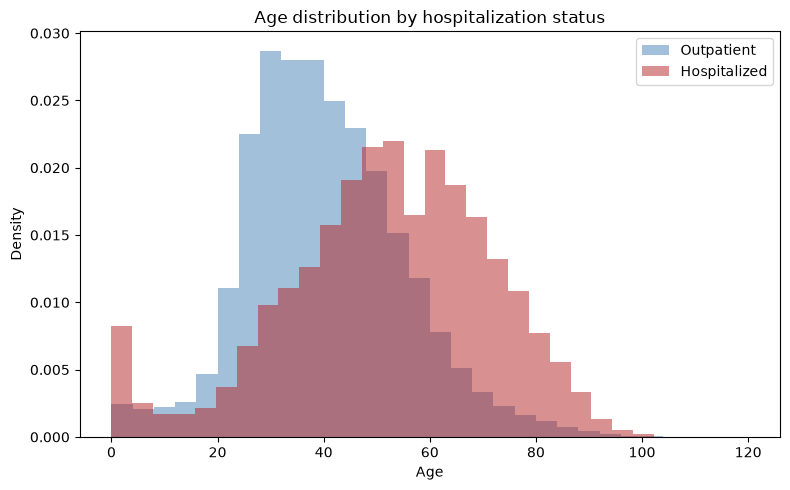

Average age of hospitalized patients: 51.80


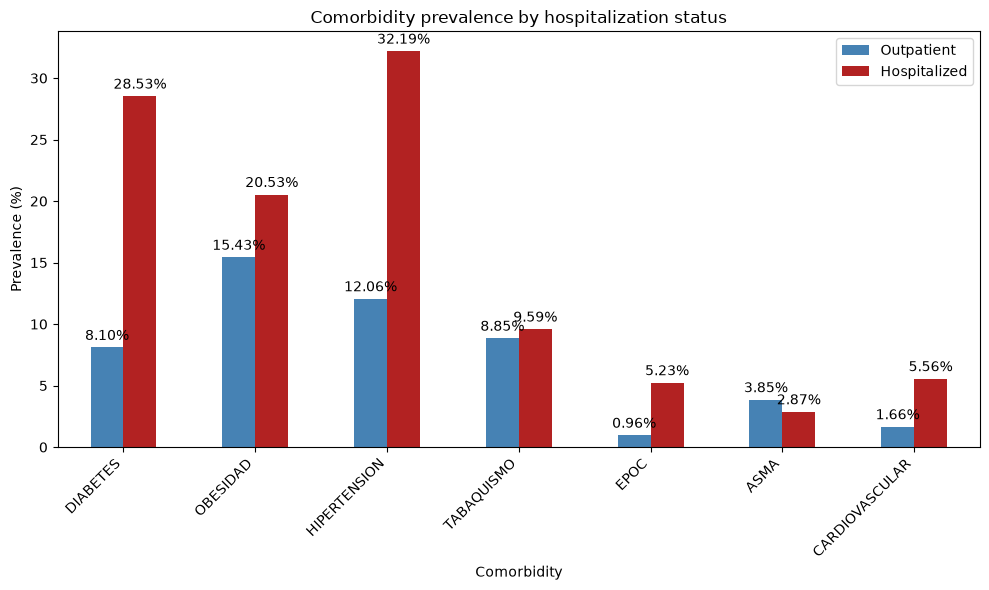

In [52]:
#verteilungen in den einzelnen gruppen
import pandas as pd
import matplotlib.pyplot as plt

# Durchschnittsalter aller Patienten
avg_age = df['EDAD'].dropna().mean()

print(f"Durchschnittsalter aller Patienten: {avg_age:.2f}")

# --- 1. Age distribution by hospitalization status ---
fig, ax = plt.subplots(figsize=(8, 5))
for status, label, color in [(1, 'Outpatient', 'steelblue'), (2, 'Hospitalized', 'firebrick')]:
    subset = df[df['TIPO_PACIENTE'] == status]['EDAD']
    ax.hist(subset, bins=30, alpha=0.5, density=True, label=label, color=color)

ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age distribution by hospitalization status')
ax.legend()
plt.tight_layout()
plt.show()

#1.1 mean age among hospitalized
hospitalized_age = df.loc[df['TIPO_PACIENTE'] == 2, 'EDAD'].dropna().mean()
print(f"Average age of hospitalized patients: {hospitalized_age:.2f}")

# --- 2. Age distribution by test result (RESULTADO) ---
# fig, ax = plt.subplots(figsize=(8, 5))
# for result, label, color in [(1, 'Positive', 'firebrick'), (2, 'Negative', 'steelblue')]:
#     subset = df[df['RESULTADO'] == result]['EDAD']
#     ax.hist(subset, bins=30, alpha=0.5, density=True, label=label, color=color)

# ax.set_xlabel('Age')
# ax.set_ylabel('Density')
# ax.set_title('Age distribution by test result')
# ax.legend()
# plt.tight_layout()
# plt.show()

# --- 3. Comorbidity prevalence by hospitalization status ---
comorbidities = ['DIABETES', 'OBESIDAD', 'HIPERTENSION', 'TABAQUISMO', 'EPOC', 'ASMA', 'CARDIOVASCULAR']

# falls TIPO_PACIENTE so codiert ist: 1 = ambulant, 2 = hospitalisiert
prevalence = {}
for col in comorbidities:
    prevalence[col] = df.groupby('TIPO_PACIENTE')[col].apply(lambda x: (x == 1).mean() * 100)

prevalence_df = pd.DataFrame(prevalence).T
prevalence_df.columns = ['Outpatient', 'Hospitalized']

fig, ax = plt.subplots(figsize=(10, 6))
bars = prevalence_df.plot(kind='bar', ax=ax, color=['steelblue', 'firebrick'])

ax.set_ylabel('Prevalence (%)')
ax.set_xlabel('Comorbidity')
ax.set_title('Comorbidity prevalence by hospitalization status')
ax.legend(title='')
plt.xticks(rotation=45, ha='right')

# Prozentwerte an die Balken schreiben
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

# # --- 4. Sex distribution by hospitalization status ---
# sex_ct = pd.crosstab(df['TIPO_PACIENTE'], df['SEXO'], normalize='index') * 100

# fig, ax = plt.subplots(figsize=(6, 5))
# sex_ct.plot(kind='bar', ax=ax, color=['steelblue', 'firebrick'])
# ax.set_ylabel('Share (%)')
# ax.set_xlabel('TIPO_PACIENTE')
# ax.set_title('Sex distribution by hospitalization status')
# ax.legend(title='SEXO')
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

# --- 5. Optional: age distribution overall vs. tested-positive subgroup ---
# useful if you want to argue: "the tested/hospitalized population skews older 
# than the general presenting population"
# fig, ax = plt.subplots(figsize=(8, 5))
# ax.hist(df['EDAD'], bins=30, alpha=0.5, density=True, label='All presenting patients', color='gray')
# ax.hist(df[df['TIPO_PACIENTE'] == 2]['EDAD'], bins=30, alpha=0.5, density=True, label='Hospitalized', color='firebrick')
# ax.set_xlabel('Age')
# ax.set_ylabel('Density')
# ax.set_title('Age distribution: all patients vs. hospitalized subgroup')
# ax.legend()
# plt.tight_layout()
# plt.show()


#### **3. N ESTIMATORS SENSITIVITY CHECK**

n_estimators=1: ROC-AUC=0.7971
n_estimators=2: ROC-AUC=0.8223
n_estimators=3: ROC-AUC=0.8307
n_estimators=4: ROC-AUC=0.8333
n_estimators=5: ROC-AUC=0.8342
n_estimators=6: ROC-AUC=0.8363
n_estimators=7: ROC-AUC=0.8377
n_estimators=8: ROC-AUC=0.8377
n_estimators=9: ROC-AUC=0.8382
n_estimators=10: ROC-AUC=0.8386
n_estimators=11: ROC-AUC=0.8393
n_estimators=12: ROC-AUC=0.8394
n_estimators=13: ROC-AUC=0.8401
n_estimators=14: ROC-AUC=0.8401


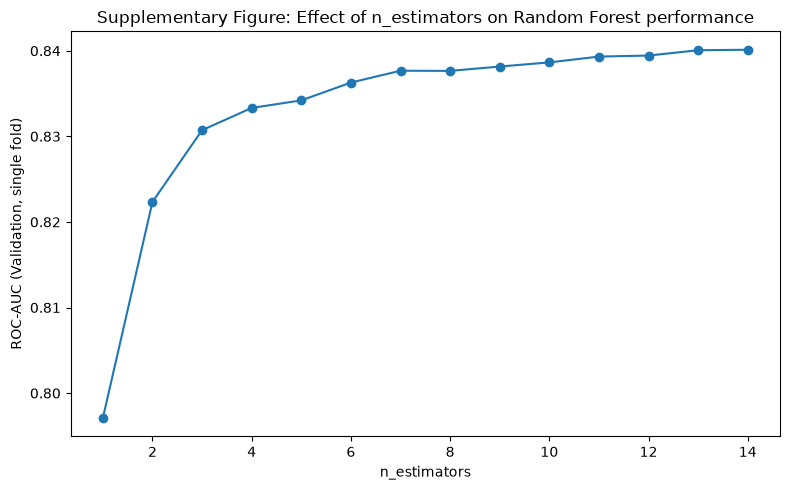

In [21]:
# Supplementary: n_estimators sensitivity check (single fold, not part of main hyperparameter search)
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

train_pos, val_pos = cv_splits[-1]  # größter, stabilster Fold

X_fold_train = X_learning.iloc[train_pos]
y_fold_train = y_learning.iloc[train_pos]
X_fold_val = X_learning.iloc[val_pos]
y_fold_val = y_learning.iloc[val_pos]

n_estimators_range = range(1, 15)
scores = []

for n in n_estimators_range:
    pipeline_test = Pipeline([
        ('sentinel_handler', SentinelHandler()),
        ('model', RandomForestClassifier(n_estimators=n, random_state=random_state, max_depth= 15))
    ])
    pipeline_test.fit(X_fold_train, y_fold_train)
    y_proba = pipeline_test.predict_proba(X_fold_val)[:, 1]
    auc = roc_auc_score(y_fold_val, y_proba)
    scores.append(auc)
    print(f"n_estimators={n}: ROC-AUC={auc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(n_estimators_range), scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC (Validation, single fold)')
plt.title('Supplementary Figure: Effect of n_estimators on Random Forest performance')
plt.tight_layout()
plt.savefig('supplementary_n_estimators.png', dpi=150)
plt.show()

#### **4. FEATURES SENSITIVITY CHECK**

max_features=sqrt: ROC-AUC=0.7943
max_features=log2: ROC-AUC=0.7943
max_features=0.5: ROC-AUC=0.7960
max_features=None: ROC-AUC=0.7947


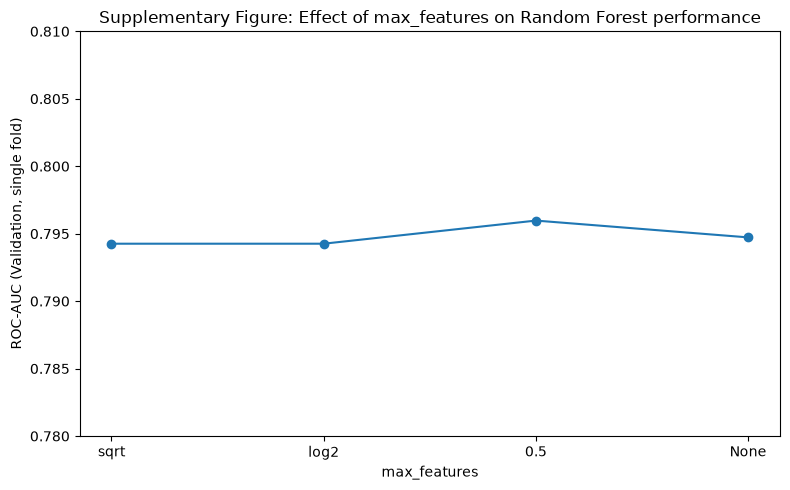

In [58]:
# Supplementary: max_features sensitivity check (single fold, not part of main hyperparameter search)
import matplotlib.pyplot as plt

max_features_options = ['sqrt', 'log2', 0.5, None]
scores_mf = []

for mf in max_features_options:
    pipeline_test = Pipeline([
        ('sentinel_handler', SentinelHandler()),
        ('model', RandomForestClassifier(n_estimators=200, max_features=mf, random_state=random_state))
    ])
    pipeline_test.fit(X_fold_train, y_fold_train)
    y_proba = pipeline_test.predict_proba(X_fold_val)[:, 1]
    auc = roc_auc_score(y_fold_val, y_proba)
    scores_mf.append(auc)
    print(f"max_features={mf}: ROC-AUC={auc:.4f}")

# Labels für die x-Achse (None lesbar machen)
labels = [str(mf) for mf in max_features_options]

plt.figure(figsize=(8, 5))
plt.plot(labels, scores_mf, marker='o')
plt.xlabel('max_features')
plt.ylabel('ROC-AUC (Validation, single fold)')
plt.title('Supplementary Figure: Effect of max_features on Random Forest performance')
plt.ylim(0.78, 0.81)  # engerer Bereich, damit der kleine Unterschied sichtbar wird
plt.tight_layout()
plt.savefig('supplementary_max_features.png', dpi=150)
plt.show()

## **Helpful Stuff**

Typische Beispiele, was darunter fällt:

Wer wurde überhaupt erfasst (Sampling-Bias)?

Nur Patienten, die zu einer der 475 Sentinel-Einrichtungen gegangen sind – nicht alle Infizierten, nicht die Gesamtbevölkerung
Asymptomatische Personen fehlen komplett


Wie wurde gemessen/erhoben (Measurement-Bias)?

Testrationierung: 100% schwere Fälle getestet, nur 10% milde Fälle → das Testergebnis selbst ist verzerrt erhoben, nicht zufällig
Manche Variablen werden möglicherweise unterschiedlich dokumentiert je nach Klinik/Personal


Zeitliche Einschränkungen

Nur Jan–Juni 2020 → frühe Pandemiephase, andere Virusvarianten, kein Impfstatus vorhanden, weniger klinische Erfahrung im Umgang mit COVID zu dieser Zeit als später


Demografische Einseitigkeit

Fast nur mexikanische Patienten (99,25%) → Generalisierbarkeit auf andere Länder fraglich

In [ ]:
import sys
print(sys.executable)
#activate kernel via
# python -m ipykernel install --user --name=project_venv --display-name "Python (project venv)"

#fix for encoding issue in "PAIS_NACIONALIDAD"
df["PAIS_NACIONALIDAD"] = df["PAIS_NACIONALIDAD"].str.encode("latin-1", errors="ignore").str.decode("utf-8", errors="ignore")

c:\Users\gewue\OneDrive\Dokumente\2026\MSc_Computational_Sciences_with_Focus_on_Theoretical_Chemistry\machine_learning\project\venv\Scripts\python.exe
